# Questions

In [ ]:
        Part 1: data Exploration and Pre-processing

1) load the given dataset 
2) Print the unique values in all columns
3) Fill nan value with ‘other’
4) Fill nan in agent with mean of agent columns
5) Drop all the remaining null values
6) Plot the count of adult and children with help of a bar plot
7) Perform Label encoding on categorical columns

        Part 2:  Model Building

1. Create features and target data
2. Split into training & testing
3. Apply Random forest classifier on data
4. Create function which show Precision score, recall score, accuracy, classification report and confusion matrix

# 1) load the given dataset 

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

In [3]:
cd C:\Users\dell\OneDrive\Desktop\Finger Tips\Machine learning\Projects\Projects datafile

C:\Users\dell\OneDrive\Desktop\Finger Tips\Machine learning\Projects\Projects datafile


In [4]:
data=pd.read_csv("Random Forest Hotel Cancellation Prediction Analysis.txt")

# 2) Print the unique values in all columns

In [ ]:
data.nunique()

# 3) Fill nan value with ‘other’

In [ ]:
data.isnull().sum()

# 4) Fill nan in agent with mean of agent columns

In [5]:
data["agent"].mean()

np.float64(86.69338185346919)

In [6]:
data["agent"].fillna(86.69 , inplace = True)

# 5) Drop all the remaining null values


In [7]:
data.dropna(inplace=True,ignore_index=True)

# 6) Plot the count of adult and children with help of a bar plot

In [9]:
adult_count = data["adults"].count()

In [10]:
children_count = data["children"].count()

In [11]:
import matplotlib.pyplot as plt

<BarContainer object of 2 artists>

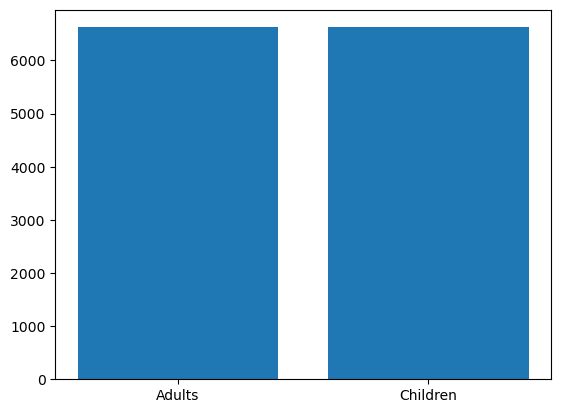

In [12]:
plt.bar(["Adults", "Children"], [adult_count, children_count])

# # 7) Perform Label encoding on categorical columns

Ordinal encoding

In [13]:
data["arrival_date_month"]=data["arrival_date_month"].replace(['July', 'August', 'September', 'October', 'November', 'December',
       'January', 'February', 'March', 'April', 'May', 'June'],[7,8,9,10,11,12,1,2,3,4,5,6])

In [14]:
data["reserved_room_type"]=data["reserved_room_type"].replace(['C', 'A', 'D', 'E', 'G', 'F', 'H', 'L', 'B', 'P'],[3,1,4,5,7,6,8,12,2,16])

In [15]:
data["assigned_room_type"]=data["assigned_room_type"].replace(['C', 'A', 'D', 'E', 'G', 'F', 'I', 'B', 'H', 'L', 'K', 'P'],[3,1,4,5,7,6,9,2,8,12,11,16])

 one-hot-encoding

In [16]:
distribution_channel = pd.get_dummies(data["distribution_channel"])

In [17]:
meal = pd.get_dummies(data["meal"])

In [18]:
hotel = pd.get_dummies(data["hotel"])

In [19]:
deposite_type = pd.get_dummies(data["deposit_type"])

In [20]:
customer_type = pd.get_dummies(data["customer_type"])

In [21]:
reservation_status = pd.get_dummies(data["reservation_status"])

In [22]:
data = pd.concat([data,distribution_channel,meal,hotel,deposite_type,customer_type,reservation_status],axis = 1)

Label encoder

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
encoder = LabelEncoder()

In [25]:
data["market_segment"] = encoder.fit_transform(data["market_segment"])

In [26]:
data["country"] = encoder.fit_transform(data["country"])

Robust scalling

In [27]:
from sklearn.preprocessing import RobustScaler

In [28]:
scaler = RobustScaler()

In [29]:
data["agent"] = scaler.fit_transform(data[["agent"]])

In [30]:
data["lead_time"] = scaler.fit_transform(data[["lead_time"]])

In [31]:
data["stays_in_weekend_nights"] = scaler.fit_transform(data[["stays_in_weekend_nights"]])

In [32]:
data["children"] = scaler.fit_transform(data[["children"]])

In [33]:
data["is_repeated_guest"] = scaler.fit_transform(data[["is_repeated_guest"]])

In [34]:
data["previous_bookings_not_canceled"] = scaler.fit_transform(data[["previous_bookings_not_canceled"]])

In [35]:
data["booking_changes"] = scaler.fit_transform(data[["booking_changes"]])

In [36]:
data["days_in_waiting_list"] = scaler.fit_transform(data[["days_in_waiting_list"]])

In [37]:
data["required_car_parking_spaces"] = scaler.fit_transform(data[["required_car_parking_spaces"]])

In [38]:
data["total_of_special_requests"] = scaler.fit_transform(data[["total_of_special_requests"]])

In [41]:
data["reservation_status_date"] = pd.to_datetime(data["reservation_status_date"],format="%d/%m/%Y")

In [42]:
data["reservation_status_day"]= data["reservation_status_date"].dt.day

In [43]:
data["reservation_status_month"]= data["reservation_status_date"].dt.month

In [44]:
data["reservation_status_year"]= data["reservation_status_date"].dt.year

In [45]:
data.drop(["distribution_channel","meal","hotel","deposit_type","customer_type","reservation_status","reservation_status_date","company"],axis =1,inplace=True)

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6623 entries, 0 to 6622
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   is_canceled                     6623 non-null   int64  
 1   lead_time                       6623 non-null   float64
 2   arrival_date_year               6623 non-null   int64  
 3   arrival_date_month              6623 non-null   int64  
 4   arrival_date_week_number        6623 non-null   int64  
 5   arrival_date_day_of_month       6623 non-null   int64  
 6   stays_in_weekend_nights         6623 non-null   float64
 7   stays_in_week_nights            6623 non-null   int64  
 8   adults                          6623 non-null   int64  
 9   children                        6623 non-null   float64
 10  babies                          6623 non-null   int64  
 11  country                         6623 non-null   int64  
 12  market_segment                  66

# 1. Create features and target data

In [55]:
x = data.drop("is_canceled",axis =1)
y = data["is_canceled"]

# 2. Split into training & testing

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2 , random_state=42)

# 3. Apply Random forest classifier on data

In [58]:
from sklearn.ensemble import RandomForestRegressor

In [59]:
model = RandomForestRegressor()

In [60]:
model.fit(x_train,y_train)

RandomForestRegressor()

# 4. Create function which show Precision score, recall score, accuracy, classification report and confusion matrix

In [64]:
yp = model.predict(x_test)

In [65]:
from sklearn.metrics import precision_score,recall_score,accuracy_score,classification_report,confusion_matrix

In [72]:
def calculation(y_test,yp):
    print("Pricision score :-",precision_score(y_test,yp))
    print("-----------------------------------------------------------")
    print("recall score :-",recall_score(y_test,yp))
    print("-----------------------------------------------------------")
    print("accuracy :-",accuracy_score(y_test,yp))
    print("-----------------------------------------------------------")
    print("\nclassification_report:\n")
    print("classification_report :-",classification_report(y_test,yp))
    print("-----------------------------------------------------------")
    print("\nconfusion_metrics:\n")
    print("confusion_metrics :-",confusion_matrix(y_test,yp))

In [73]:
calculation(y_test,yp)

Pricision score :- 1.0
-----------------------------------------------------------
recall score :- 1.0
-----------------------------------------------------------
accuracy :- 1.0
-----------------------------------------------------------

classification_report:

classification_report :-               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1076
           1       1.00      1.00      1.00       249

    accuracy                           1.00      1325
   macro avg       1.00      1.00      1.00      1325
weighted avg       1.00      1.00      1.00      1325

-----------------------------------------------------------

confusion_metrics:

confusion_metrics :- [[1076    0]
 [   0  249]]
